# Retail Sales Forecasting

Predicting daily unit sales per store/department from historical sales,
promotions, holidays, and weather using a synthetic dataset that mirrors
a typical retail POS export (5 stores x 4 departments x 3 years of daily data).

**Workflow:** EDA -> time-aware feature engineering -> model comparison
(Linear Regression, Random Forest, Gradient Boosting) -> evaluation on a
held-out future period.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load data

In [2]:
df = pd.read_csv("../data/raw/retail_sales.csv", parse_dates=["date"])
print(df.shape)
df.head()


(21900, 9)


,date,store_id,dept_id,units_sold,unit_price,is_promo,is_holiday,temperature_c,revenue
0,2021-01-01,1,1,749,29.55,1,1,9.2,22132.95
1,2021-01-02,1,1,372,35.25,0,0,9.6,13113.00
2,2021-01-03,1,1,363,32.88,0,0,10.4,11935.44
3,2021-01-04,1,1,480,29.47,1,0,8.4,14145.60
4,2021-01-05,1,1,280,34.74,0,0,9.3,9727.20


In [3]:
df.info()
df.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 21900 entries, 0 to 21899
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           21900 non-null  datetime64[us]
 1   store_id       21900 non-null  int64         
 2   dept_id        21900 non-null  int64         
 3   units_sold     21900 non-null  int64         
 4   unit_price     21900 non-null  float64       
 5   is_promo       21900 non-null  int64         
 6   is_holiday     21900 non-null  int64         
 7   temperature_c  21900 non-null  float64       
 8   revenue        21900 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(5)
memory usage: 1.5 MB


date             0
store_id         0
dept_id          0
units_sold       0
unit_price       0
is_promo         0
is_holiday       0
temperature_c    0
revenue          0
dtype: int64

## 2. Exploratory analysis

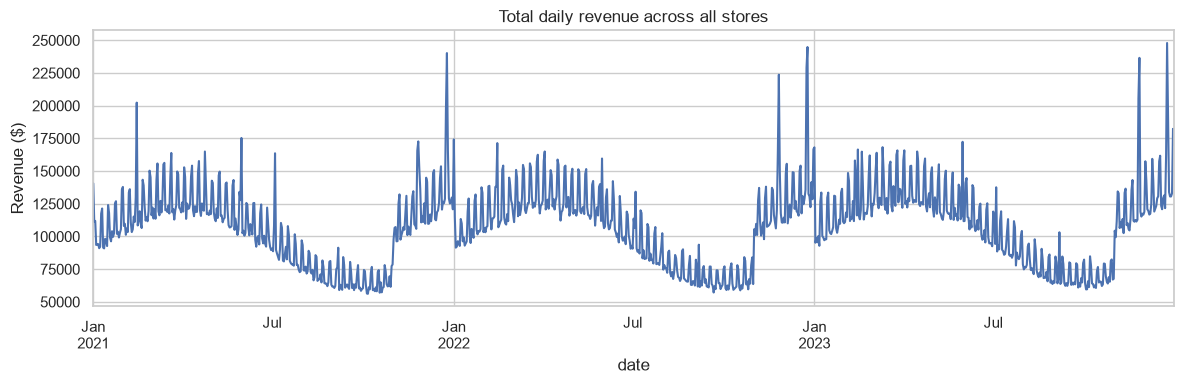

In [4]:
daily = df.groupby("date")["revenue"].sum()

fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax)
ax.set_title("Total daily revenue across all stores")
ax.set_ylabel("Revenue ($)")
plt.tight_layout()
plt.show()


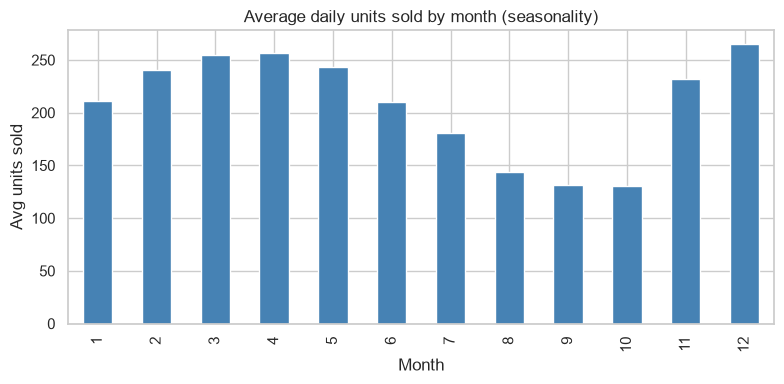

In [5]:
monthly_avg = df.assign(month=df["date"].dt.month).groupby("month")["units_sold"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
monthly_avg.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Average daily units sold by month (seasonality)")
ax.set_xlabel("Month")
ax.set_ylabel("Avg units sold")
plt.tight_layout()
plt.show()


In [6]:
promo_effect = df.groupby("is_promo")["units_sold"].mean()
holiday_effect = df.groupby("is_holiday")["units_sold"].mean()
print("Avg units sold, promo vs non-promo:")
print(promo_effect)
print()
print("Avg units sold, holiday vs non-holiday:")
print(holiday_effect)


Avg units sold, promo vs non-promo:
is_promo
0    195.319822
1    302.957439
Name: units_sold, dtype: float64

Avg units sold, holiday vs non-holiday:
is_holiday
0    204.741713
1    342.481481
Name: units_sold, dtype: float64


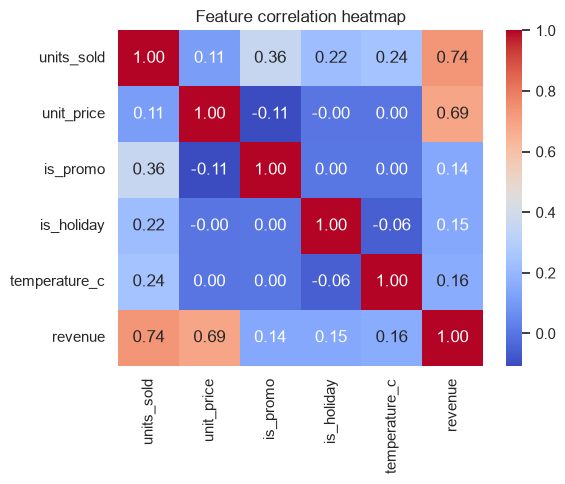

In [7]:
numeric_cols = ["units_sold", "unit_price", "is_promo", "is_holiday", "temperature_c", "revenue"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Feature correlation heatmap")
plt.tight_layout()
plt.show()


## 3. Feature engineering

Time-series models need lag/rolling features and calendar signals rather
than raw dates. Lags are computed **per store/department series** so
history never leaks across unrelated series.


In [8]:
data = df.sort_values(["store_id", "dept_id", "date"]).copy()

data["day_of_week"] = data["date"].dt.dayofweek
data["month"] = data["date"].dt.month
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

group = data.groupby(["store_id", "dept_id"])["units_sold"]
data["lag_7"] = group.shift(7)
data["lag_14"] = group.shift(14)
data["rolling_mean_7"] = group.shift(1).rolling(7).mean()
data["rolling_mean_28"] = group.shift(1).rolling(28).mean()

data = data.dropna().reset_index(drop=True)
data.shape


(21340, 16)

## 4. Train/test split (time-based)

In [9]:
cutoff = data["date"].max() - pd.Timedelta(days=90)
train = data[data["date"] <= cutoff]
test = data[data["date"] > cutoff]

feature_cols = [
    "store_id", "dept_id", "unit_price", "is_promo", "is_holiday",
    "temperature_c", "day_of_week", "month", "is_weekend",
    "lag_7", "lag_14", "rolling_mean_7", "rolling_mean_28",
]
target_col = "units_sold"

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train period: {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Test period:  {test['date'].min().date()} to {test['date'].max().date()}")


Train: (19540, 13), Test: (1800, 13)
Train period: 2021-01-29 to 2023-10-02
Test period:  2023-10-03 to 2023-12-31


## 5. Model training and comparison

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2": r2_score(y_test, preds),
    }

results_df = pd.DataFrame(results).T.round(3)
results_df


,MAE,RMSE,R2
Linear Regression,27.296,40.471,0.865
Random Forest,20.247,30.833,0.922
Gradient Boosting,18.976,28.069,0.935


## 6. Evaluation

Best model by RMSE: Gradient Boosting


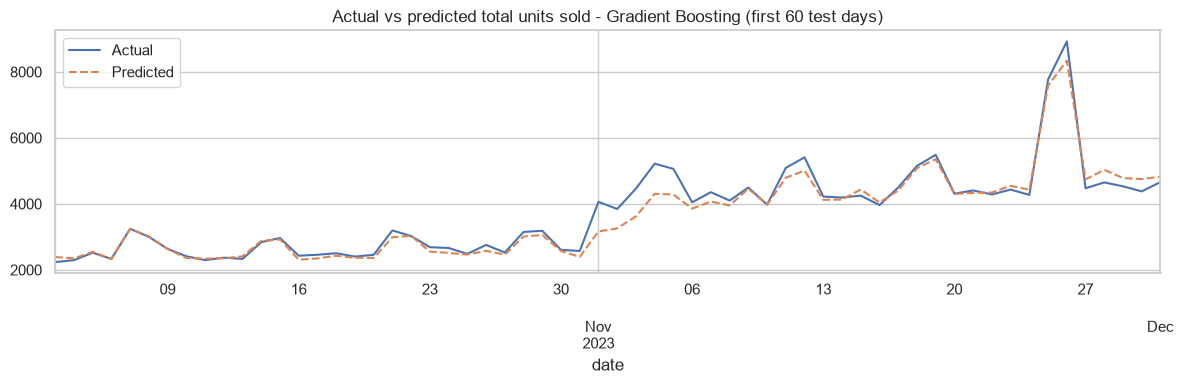

In [11]:
best_model_name = results_df["RMSE"].idxmin()
best_preds = predictions[best_model_name]
print(f"Best model by RMSE: {best_model_name}")

fig, ax = plt.subplots(figsize=(12, 4))
sample = test.assign(pred=best_preds).groupby("date")[["units_sold", "pred"]].sum().iloc[:60]
sample["units_sold"].plot(ax=ax, label="Actual")
sample["pred"].plot(ax=ax, label="Predicted", linestyle="--")
ax.set_title(f"Actual vs predicted total units sold - {best_model_name} (first 60 test days)")
ax.legend()
plt.tight_layout()
plt.show()


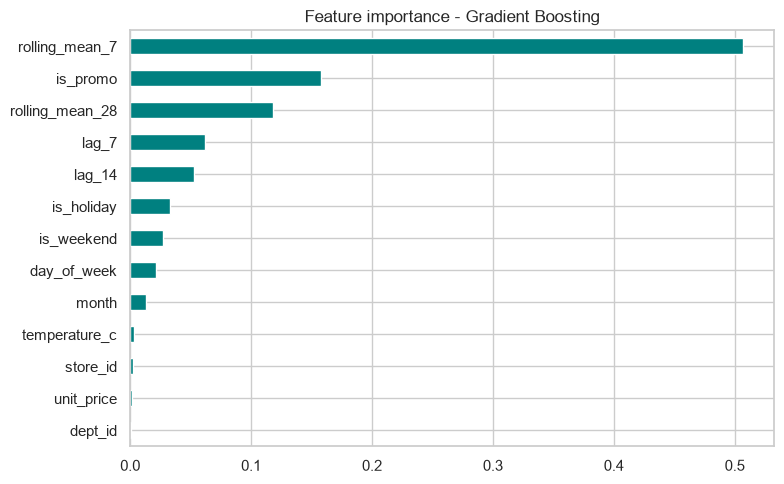

In [12]:
best_model = models[best_model_name]
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot(kind="barh", ax=ax, color="teal")
    ax.invert_yaxis()
    ax.set_title(f"Feature importance - {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(best_model.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
    print(coefs)


## 7. Conclusion

- Recent history (`lag_7`, `rolling_mean_7`/`rolling_mean_28`) dominates predictive
  power, as expected for retail demand -- yesterday and last week are the strongest
  signal for tomorrow.
- Promotions and holidays produce a clear, learnable lift in units sold.
- Tree-based ensembles capture the non-linear interaction between promo/holiday
  flags and seasonality better than plain linear regression, at the cost of
  interpretability.
- Next steps for a production version: per-series backtesting (rolling-origin
  cross-validation), hierarchical reconciliation across store/department levels,
  and adding external regressors (e.g. local events, competitor pricing).
